`conda activate r_python`

In [1]:
suppressPackageStartupMessages({
    library(ggplot2)
    library(reticulate)
    library(Seurat)
    library(dplyr)
    library(tidyr)
    library(tibble)
    library(stringr)
    library(dittoSeq)
    library(future)
    library(data.table)
    plan("multiprocess", workers = 12)
    options(future.globals.maxSize = 1000 * 1024^5)
    options(stringsAsFactors = FALSE)
    set.seed(123)
})

In [2]:
# taken from Azimuth reference (Bakken et al, bioRxiv 2020)
ascites <- readRDS('/hpc/pmc_stunnenberg/cruiz/scRNA/analysis/pmc_patients/dipg_ascitis/deep_sequencing/for_publication/data/ascites/dmg_ascites_prettx_posttx.rds')
ascites

An object of class Seurat 
43133 features across 19804 samples within 2 assays 
Active assay: SCT (21037 features, 3000 variable features)
 1 other assay present: RNA
 2 dimensional reductions calculated: mnn, umap

# Nieto et al. ***Genome Research*** 2021. - https://www.genome.org/cgi/doi/10.1101/gr.273300.120

In [4]:
reference <- readRDS('references//panimmune//TICAtlas_subset.rds')
reference

An object of class Seurat 
19157 features across 171379 samples within 1 assay 
Active assay: RNA (19157 features, 0 variable features)
 1 dimensional reduction calculated: umap

### Reference mapping

In [ ]:
myeloid <- subset(ascites, idents = c('myeloid'), invert=TRUE)

In [10]:
anchors <- FindTransferAnchors(
  reference = reference,
  query = myeloid,
  features = rownames(reference[["RNA"]]),
  normalization.method = "LogNormalize",
  reference.reduction = "pca",
  dims = 1:50
)

Warning message:
“3061 features of the features specified were not present in both the reference query assays. 
Continuing with remaining 16096 features.”
Projecting cell embeddings

Finding neighborhoods

Finding anchors

	Found 3651 anchors

Filtering anchors

	Retained 1872 anchors



`Map Query` functions run separately

In [11]:
myeloid <- TransferData(
  anchorset = anchors, 
  reference = reference,
  query = myeloid,
  refdata = list(
      nieto.lv2 = 'lv2_annot'
  )
)

Finding integration vectors

Finding integration vector weights

Predicting cell labels

Warning message:
“Keys should be one or more alphanumeric characters followed by an underscore, setting key from predictionscorenieto.lv2_ to predictionscorenietolv2_”


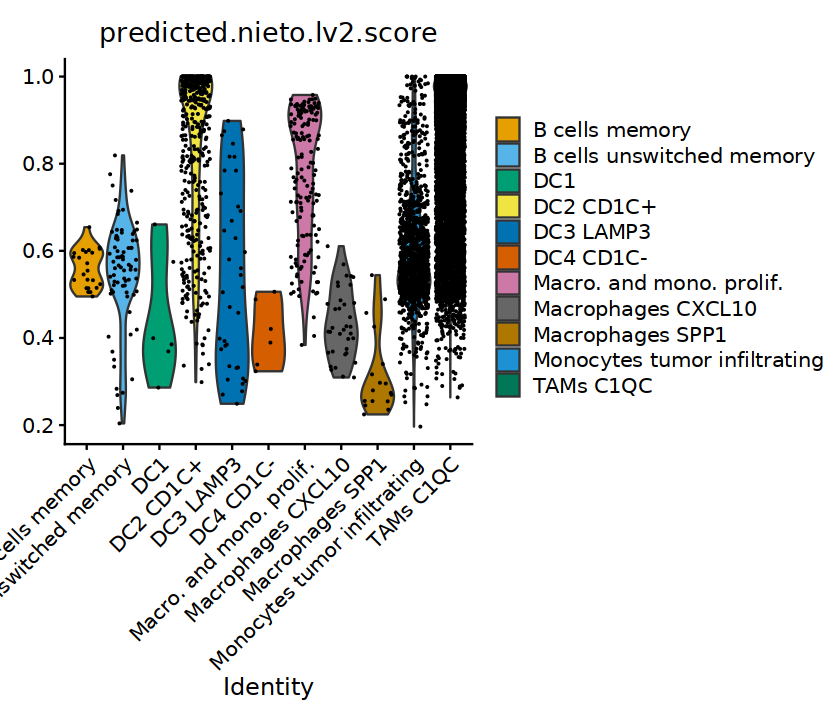

In [14]:
options(repr.plot.height = 6, repr.plot.width = 7)
VlnPlot(myeloid, features = "predicted.nieto.lv2.score", 
        group.by = 'predicted.nieto.lv2', cols=dittoColors()) 

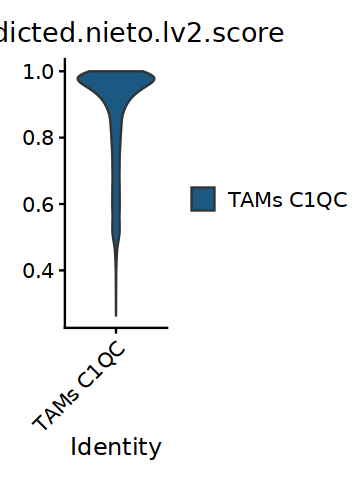

In [6]:
options(repr.plot.height = 4, repr.plot.width = 3)
VlnPlot(subset(myeloid, predicted.nieto.lv2=='TAMs C1QC'), features = "predicted.nieto.lv2.score", 
        group.by = 'predicted.nieto.lv2', cols='#1b5982', pt.size=0) 

In [7]:
ggsave('../figures/prediction_ascites_tams_nieto.pdf', height = 4, width = 3)